<a href="https://colab.research.google.com/github/stefanogiagu/corso_AI_2026/blob/main/ReadGraph_example.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Colorazione di grafi con Graph Neural Networks e minimizzazione differenziabile dell'energia di Potts

**Gruppo 6:** Mauro Bellucci, Marta Pizzo, Marco Tornambè

**Corso:** Metodi AI per la Fisica - ML 2026


## Sommario
In questo lavoro viene presentato un metodo basato su Graph Neural Networks (GNN) per
affrontare il problema della colorazione di grafi tramite ottimizzazione differenziabile.
La GNN assegna a ciascun nodo una distribuzione di probabilità sui colori disponibili e
viene addestrata minimizzando un'energia di Potts differenziabile, arricchita da un termine
entropico con peso decrescente, utilizzando l'ottimizzatore Adam di PyTorch. La colorazione
discreta finale si ottiene con un argmax sull'output della rete. Il metodo è stato applicato
a due grafi in formato DIMACS: `g11` (25 nodi, 160 archi) e `g17` (128
nodi, 2113 archi). Per `g11` è stata trovata una colorazione valida con $c = 5$
colori in 5 esecuzioni su 50, stabilendo $\chi(\texttt{g11}) \leq 5$. Per `g17`
è stata trovata una colorazione valida con $c = 35$ colori in 1 esecuzione su 50,
stabilendo $\chi(\texttt{g17}) \leq 36$.

## Introduzione al problema

Il problema della **colorazione di grafi** è così definito: dato un grafo non orientato $G = (V, E)$,
dove $V$ è l'insieme dei nodi e $E$ quello degli archi, si vuole assegnare a ciascun nodo
$i \in V$ un colore scelto da un insieme finito di $c$ colori, in modo tale che nessuna
coppia di nodi adiacenti condivida lo stesso colore:

$$
\forall\,(i,j) \in E: \quad \mathrm{color}(i) \neq \mathrm{color}(j).
$$

Il **numero cromatico** $\chi(G)$ è il minimo intero $c$ per cui esiste una
colorazione valida di $G$. Determinare esattamente $\chi(G)$ è un problema NP-completo
per grafi generali: non è noto alcun algoritmo polinomiale esatto, e i metodi di ricerca
esaustiva diventano proibitivi già per grafi di medie dimensioni.

In questo progetto viene adottato un approccio basato su reti neurali:
anziché cercare la soluzione con un algoritmo combinatorio esatto, si formula il problema
come *ottimizzazione differenziabile* e lo si risolve con una GNN addestrata
direttamente sul grafo di interesse.

I due grafi assegnati al Gruppo 6 sono stati scaricati dal repository del corso in formato
DIMACS standard:
- `g11`: 25 nodi, 160 archi non orientati.
- `g17`: 128 nodi, 2113 archi non orientati.


Come confronto iniziale, l'algoritmo greedy ``greedy_color`` di NetworkX (strategia
*largest\_first*, che ordina i nodi per grado decrescente) ha prodotto una
colorazione con $c = 7$ colori per `g11` e $c = 32$ colori per `g17`.
Questi valori costituiscono limiti superiori di riferimento per $\chi(G)$.


In [1]:
!pip install torch_geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 74.5 MB/s eta 0:00:00


In [2]:
print('Downloading datasets')

!rm -rf g11.col
!wget https://raw.githubusercontent.com/stefanogiagu/corso_AI_2026/main/grafi/g11.col

!rm -rf g17.col
!wget https://raw.githubusercontent.com/stefanogiagu/corso_AI_2026/main/grafi/g17.col

print('Done')

--2026-06-05 17:52:20--  https://raw.githubusercontent.com/stefanogiagu/corso_AI_2026/main/grafi/g11.col
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.111.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2504 (2.4K) [text/plain]
Saving to: ‘g11.col’

g11.col             100%[===================>]   2.45K  --.-KB/s    in 0s      

2026-06-05 17:52:20 (56.9 MB/s) - ‘g11.col’ saved [2504/2504]

--2026-06-05 17:52:20--  https://raw.githubusercontent.com/stefanogiagu/corso_AI_2026/main/grafi/g17.col
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 35514 (35K) [text/plain]
Saving to: ‘g1

In [3]:
from pathlib import Path
from typing import Optional, Tuple, List, Dict, Union
import urllib.request

import torch
from torch_geometric.data import Data


def read_dimacs_col(
    path: Union[str, Path],
    make_undirected: bool = True,
    remove_self_loops: bool = True,
    dtype: torch.dtype = torch.float32,
) -> Data:
    """
    Read a graph coloring instance in DIMACS .col format and convert it
    to a PyTorch Geometric Data object.

    Expected DIMACS format:
        c comment lines
        p edge <num_nodes> <num_edges>
        e <u> <v>

    DIMACS nodes are usually 1-indexed.
    PyTorch Geometric expects 0-indexed node indices.

    Parameters
    ----------
    path:
        Path to the .col file.
    make_undirected:
        If True, each edge (u, v) is stored as both (u, v) and (v, u)
        in edge_index, as commonly expected by PyG message passing layers.
    remove_self_loops:
        If True, discard edges of the form (u, u).
    dtype:
        dtype for the default node features.

    Returns
    -------
    data:
        torch_geometric.data.Data object with fields:
            x: dummy node features, shape [num_nodes, 1]
            edge_index: graph connectivity, shape [2, num_edges_pyg]
            num_nodes: number of nodes
            name: file stem
            num_edges_dimacs: number of undirected edges declared/read
    """

    path = Path(path)

    if path.suffix == ".b" or path.name.endswith(".col.b"):
        raise ValueError(
            f"{path.name} appears to be a binary .col.b file. "
            "This parser only supports standard text DIMACS .col files."
        )

    num_nodes: Optional[int] = None
    declared_num_edges: Optional[int] = None
    edges: List[Tuple[int, int]] = []

    with path.open("r", encoding="utf-8", errors="ignore") as f:
        for line_number, line in enumerate(f, start=1):
            line = line.strip()

            if not line:
                continue

            parts = line.split()

            # Comment line
            if parts[0] == "c":
                continue

            # Problem line: p edge n m
            if parts[0] == "p":
                if len(parts) < 4:
                    raise ValueError(
                        f"Malformed problem line at line {line_number}: {line}"
                    )

                problem_type = parts[1]
                if problem_type not in {"edge", "col"}:
                    # Most coloring instances use 'p edge n m'
                    # but we allow other variants with a warning-like behavior.
                    pass

                num_nodes = int(parts[2])
                declared_num_edges = int(parts[3])
                continue

            # Edge line: e u v
            if parts[0] == "e":
                if len(parts) < 3:
                    raise ValueError(
                        f"Malformed edge line at line {line_number}: {line}"
                    )

                # Convert from 1-indexed DIMACS to 0-indexed PyG.
                u = int(parts[1]) - 1
                v = int(parts[2]) - 1

                if remove_self_loops and u == v:
                    continue

                edges.append((u, v))
                continue

            # Ignore unknown line types, but this can be made stricter if desired.
            # raise ValueError(f"Unknown line type at line {line_number}: {line}")

    if num_nodes is None:
        raise ValueError(f"No problem line 'p edge n m' found in {path}")

    if len(edges) == 0:
        edge_index = torch.empty((2, 0), dtype=torch.long)
    else:
        # Remove duplicate undirected edges robustly.
        # DIMACS stores undirected edges; we canonicalize as (min, max).
        unique_edges = set()
        for u, v in edges:
            if u < 0 or v < 0 or u >= num_nodes or v >= num_nodes:
                raise ValueError(
                    f"Edge ({u + 1}, {v + 1}) out of bounds for graph "
                    f"with {num_nodes} nodes in file {path}"
                )

            a, b = min(u, v), max(u, v)
            unique_edges.add((a, b))

        edge_list = sorted(unique_edges)

        if make_undirected:
            pyg_edges = edge_list + [(v, u) for u, v in edge_list]
        else:
            pyg_edges = edge_list

        edge_index = torch.tensor(pyg_edges, dtype=torch.long).t().contiguous()

    # Dummy node features.
    # For graph coloring, the learnable node embeddings can be created later
    # inside the model, but PyG Data objects usually contain x.
    x = torch.ones((num_nodes, 1), dtype=dtype)

    data = Data(
        x=x,
        edge_index=edge_index,
        num_nodes=num_nodes,
    )

    data.name = path.stem.replace(".col", "")
    data.num_edges_dimacs = len(edges)
    data.num_edges_unique = edge_index.size(1) // 2 if make_undirected else edge_index.size(1)
    data.declared_num_edges = declared_num_edges

    if declared_num_edges is not None and declared_num_edges != len(edges):
        data.edge_count_warning = (
            f"Declared {declared_num_edges} edges, read {len(edges)} edge lines."
        )
    else:
        data.edge_count_warning = None

    return data

In [4]:
data11 = read_dimacs_col("g11.col")
data17 = read_dimacs_col("g17.col")

print(data11)
print("Name:", data11.name)
print("Number of nodes:", data11.num_nodes)
print("DIMACS edges:", data11.num_edges_unique)
print("PyG edge_index shape:", data11.edge_index.shape)
print('\n')
print(data17)
print("Name:", data17.name)
print("Number of nodes:", data17.num_nodes)
print("DIMACS edges:", data17.num_edges_unique)
print("PyG edge_index shape:", data17.edge_index.shape)

Data(x=[25, 1], edge_index=[2, 320], num_nodes=25, name='g11', num_edges_dimacs=320, num_edges_unique=160, declared_num_edges=320)
Name: g11
Number of nodes: 25
DIMACS edges: 160
PyG edge_index shape: torch.Size([2, 320])


Data(x=[128, 1], edge_index=[2, 4226], num_nodes=128, name='g17', num_edges_dimacs=4226, num_edges_unique=2113, declared_num_edges=4226)
Name: g17
Number of nodes: 128
DIMACS edges: 2113
PyG edge_index shape: torch.Size([2, 4226])


Visualizzazione dei grafi

Text(0.5, 1.0, 'G17')

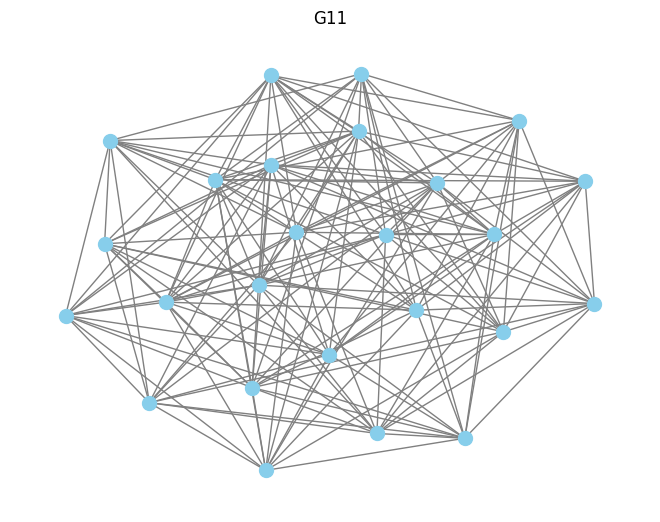

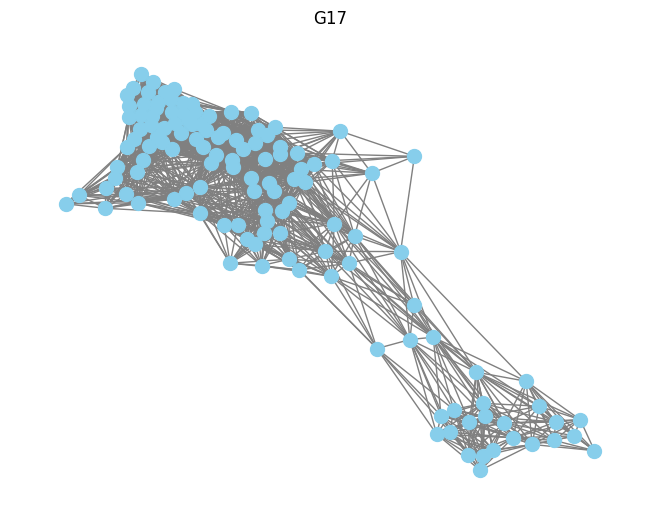

In [5]:
import matplotlib.pyplot as plt
import networkx as nx
from torch_geometric.utils import to_networkx

G = to_networkx(data11, to_undirected=True)
pos = nx.spring_layout(G)
plt.figure()
nx.draw(
    G,
    pos,
    node_color='skyblue',
    edge_color='gray',
    node_size=100,
    font_size=10,
)
plt.title('G11')

G = to_networkx(data17, to_undirected=True)
pos = nx.spring_layout(G)
plt.figure()
nx.draw(
    G,
    pos,
    node_color='skyblue',
    edge_color='gray',
    node_size=100,
    font_size=10,
)
plt.title('G17')



## Strategia Utilizzata

### Riformulazione come ottimizzazione differenziabile

L'idea centrale del metodo è quella di trasformare il problema discreto di
colorazione in un problema continuo. Invece di assegnare direttamente un colore intero a
ogni nodo, la GNN produce per ciascun nodo $i$ un vettore di probabilità sui $c$ colori
disponibili (ottenuti tramite softmax dell'output della rete):

$$
p_i = \bigl(p_{i1},\, p_{i2},\, \dots,\, p_{ic}\bigr), \qquad
    \sum_{k=1}^c p_{ik} = 1, \quad p_{ik} \geq 0.
$$

Il valore $p_{ik}$ rappresenta la probabilità assegnata al colore $k$
per il nodo $i$.
L'addestramento minimizza una funzione di perdita differenziabile che
penalizza le assegnazioni in conflitto. Al termine, la colorazione discreta si ottiene
tramite argmax.

### Funzione di loss: energia di Potts differenziabile
La funzione di perdita è ispirata all'**hamiltoniana antiferromagnetica del modello
di Potts**. Nel modello di Potts antiferromagnetico su reticolo, l'energia è minima quando
spin adiacenti si trovano in stati diversi. Pre ottenere una funzione differenziabile sui vettori di probabilità, si definisce:

$$
\mathcal{L}_{\mathrm{Potts}} = \sum_{(i,j)\in E} p_i \cdot p_j
    = \sum_{(i,j)\in E} \sum_{k=1}^c p_{ik}\, p_{jk}.
$$

Ogni termine $p_i \cdot p_j$ misura la *sovrapposizione* tra le distribuzioni di
colore dei due nodi estremi dell'arco $(i,j)$. Se i nodi tendono ad assumere lo stesso
colore, il prodotto scalare è grande (fino a 1 nel caso di vettori one-hot identici) e
contribuisce ad aumentare la loss. Se i nodi tendono a colori diversi, il prodotto è
piccolo e la loss è ridotta. Minimizzare $\mathcal{L}_{\mathrm{Potts}}$ spinge quindi la
rete a produrre assegnazioni in cui nodi adiacenti hanno colori diversi.

### Regolarizzazione con termine entropico

Per velocizzare l'addestramento (favorendo assegnazioni più nette) è stato aggiunto alla loss un termine entropico:

$$
H = -\frac{1}{|V|} \sum_{i \in V} \sum_{k=1}^c p_{ik} \log p_{ik},
$$

in modo che la loss totale sia:

$$
\mathcal{L}_{\mathrm{tot}} = \mathcal{L}_{\mathrm{Potts}} + \lambda\, H.
$$

All'inizio dell'allenamento il peso entropico è nullo, per permettere alla rete di esplorare in libertà la loss-landscape, il valore viene poi aumentato nel corso dell'addestramento.

Al termine dell'addestramento, la colorazione discreta è ottenuta assegnando a ogni nodo
il colore con probabilità massima:

$$
\mathrm{color}(i) = \arg\max_k\, p_{ik}.
$$

Il numero di **conflitti residui** $N_{\mathrm{conflicts}}$ è il numero di archi
$(i,j)$ per cui $\mathrm{color}(i) = \mathrm{color}(j)$. Una colorazione è valida se e
solo se $N_{\mathrm{conflicts}} = 0$.

Per stimare $\chi(G)$, l'intero processo (costruzione della rete, addestramento,
discretizzazione) viene ripetuto per valori crescenti di $c$, con più inizializzazioni
casuali indipendenti per ogni $c$. Il numero cromatico stimato è il minimo $c$ per cui
almeno un'esecuzione produce $N_{\mathrm{conflicts}} = 0$.


## Architettura della rete

La rete utilizzata è denominata `ColoraGrafo` ed è implementata in PyTorch con la
libreria `PyTorch Geometric`. L'architettura è composta da quattro blocchi
principali.
- **Embedding iniziale dei nodi**: A ciascun nodo $i$ è associato un vettore di embedding appreso tramite uno strato
`nn.Embedding`: ogni nodo viene identificato dal proprio indice intero e mappato in
$\mathbb{R}^h$, dove $h$ è la dimensione nascosta. Questo approccio consente alla rete di
apprendere una rappresentazione specifica per ogni nodo del grafo di input, non condizionata
da feature esterne. Poiché il metodo addestra una GNN separata per ciascun grafo, questa
scelta è coerente con l'obiettivo: ottimizzare i parametri per il singolo grafo assegnato.
- **Layer di message passing: SAGEConv**: L'embedding di ciascun nodo viene aggiornato attraverso 2 strati di convoluzione **SAGEConv**, separati da attivazioni
ReLU.
- **Layer di output e softmax**: L'output finale è prodotto da un layer lineare `nn.Linear` con $h$ neuroni in input
e $c$ neuroni in output, seguito dalla funzione softmax applicata per riga (un vettore per
nodo):
- **Parametri e configurazioni**: La dimensione nascosta è stata scelta a $h = 128$ per `g11` e $h = 256$ per
`g17` (più grande e denso). Il numero totale di parametri addestrabili, per
`g11` con $c = 5$ e $h = 64$, è circa 18\,000; per le configurazioni più grandi
(es. `g17`, $h = 256$, $c = 36$) può raggiungere alcune centinaia di migliaia.

L'architettura non include layer di dropout né normalizzazione, per mantenere
l'ottimizzazione il più semplice possibile. È disponibile un'opzione `deeper=True`
che aggiunge un terzo layer SAGEConv, non utilizzata nelle sessioni principali (poiché reti
più profonde non hanno mostrato vantaggi e rendono l'ottimizzazione più difficile).


In [6]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import SAGEConv

class ColoraGrafo(nn.Module):
    def __init__(self, num_nodes, c=5, hidden=64, deeper=False):
        super().__init__()
        self.deeper = deeper
        self.embedding = nn.Embedding(num_nodes, hidden)
        self.conv1 = SAGEConv(hidden, hidden)
        self.conv2 = SAGEConv(hidden, hidden)
        if self.deeper:
            self.conv3 = SAGEConv(hidden, hidden)
        self.fc_out = nn.Linear(hidden, c)

    def forward(self, data):
        edge_index = data.edge_index
        node_indices = torch.arange(self.embedding.num_embeddings, device=edge_index.device)
        x = self.embedding(node_indices)
        x = F.relu(self.conv1(x, edge_index))
        #x = F.dropout(x, p=0.1, training=self.training)
        x = F.relu(self.conv2(x, edge_index))
        if self.deeper:
            x = F.relu(self.conv3(x, edge_index))
        x = self.fc_out(x)
        x = F.softmax(x, dim=-1)

        return x

In [7]:
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else print('Marta puzzi non hai messo le gpu')
print('Using',device, 'device')

# esempio di modello con g11
model = ColoraGrafo(num_nodes=data11.num_nodes).to(device)
print(model)
num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("Numero di parametri trainabili:", num_params)

Using cuda device
ColoraGrafo(
  (embedding): Embedding(25, 64)
  (conv1): SAGEConv(64, 64, aggr=mean)
  (conv2): SAGEConv(64, 64, aggr=mean)
  (fc_out): Linear(in_features=64, out_features=5, bias=True)
)
Numero di parametri trainabili: 18437


# Loss, metriche e ottimizzatore

In [8]:
# definizione della loss
def potts_energy_differentiable(pred, edge_index):
    """
    colori -> [num_nodes, c]
    calcolo l'energia di potts in formato differenziabile
    """
    i, j = edge_index

    edge_energy = (pred[i]*pred[j]).sum(dim=-1)
    return edge_energy.sum()

def entropic_term(pred):
    return -((pred+1e-12).log()*pred).sum()/pred.size(dim=0)

def my_loss(pred, edge_index, ll):
    energy = potts_energy_differentiable(pred, edge_index)
    entropy = entropic_term(pred)
    return energy + ll*entropy

# come metrica utilizziamo il numero di conflitti
def pott_energy_normal(pred, edge_index):
    """
    Come prima ma con argmax prima, ritorna il numero di conflitti per 2
    """

    i, j = edge_index
    colori = pred.argmax(dim=-1)
    edge_energy = (colori[i] == colori[j]).int()
    return edge_energy.sum()/2



In [9]:
# proviamo a vedere che tutto funzioni
data11.x = torch.randn(data11.num_nodes, 1)
data11 = data11.to(device)


pred = model(data11)
loss = my_loss(pred, data11.edge_index, 0.01)
conflitti = pott_energy_normal(pred, data11.edge_index)

print('Loss: ', loss.item())
print('N conflitti: ', conflitti.item())

Loss:  64.43099212646484
N conflitti:  74.0


## Dettagli del training
L'ottimizzazione dei parametri della rete avviene tramite l'algoritmo **Adam**
(Adaptive Moment Estimation). Adam stima adattativamente il learning rate per ogni
parametro usando le prime e seconde stime dei momenti del gradiente, risultando
generalmente più robusto di SGD in presenza di superfici di perdita irregolari e non
convesse come quelle tipiche di questo problema. Il learning rate è $\eta = 0.001$.
Come numero di epoche di allenamento si è scelto:
- `g11`: 400 epoche per esecuzione.
- `g17`: 500 epoche per esecuzione nelle sessioni multiple; fino a 1000
    epoche negli esperimenti esplorativi singoli.

Il parametro $\lambda$ è impostato a $0$ per la prima metà del training, è poi progressivamente aumentato fino a 0.1 nella seconda metà.

Poiché la superficie della loss è non convessa e ricca di minimi locali, per ogni valore
di $c$ vengono eseguite **50 inizializzazioni casuali indipendenti**. A ogni
esecuzione, sia i pesi della rete che le feature di input dei nodi (vettori campionati da
$\mathcal{N}(0,1)$) vengono reinizializzati da zero. Per ogni $c$ si riportano: la media
del numero di conflitti su 50 esecuzioni, la deviazione standard e il numero di esecuzioni
che producono una colorazione valida (zero conflitti). Esempi di allenamenti sono riportati in seguito.


Come riferimento, si è calcolata una colorazione con l'algoritmo greedy ``greedy_color``
di NetworkX con strategia *largest\_first* (i nodi sono elaborati in ordine di grado
decrescente). Questa euristica classica non garantisce la colorazione ottima, ma fornisce un
limite superiore immediato per $\chi(G)$ e permette di valutare se la GNN migliora rispetto
all'approccio combinatorio semplice.


**Addestro il grafo 11**

In [10]:
# baseline greedy con greedy_color
G = to_networkx(data11, to_undirected=True)
coloring = nx.coloring.greedy_color(G, strategy="largest_first")
num_colors = max(coloring.values()) + 1
print("Baseline greedy: c=", num_colors)

Baseline greedy: c= 7


In [12]:
import torch.optim as optim
num_epochs = 400
c=7
# imposto l'iper-parametro
LAMBDA_MAX = 0.1
RAMP_EPOCHS = 200  # massimo valore dopo 200 epoche
#data11.x = torch.randn(data11.num_nodes, 1)
data = data11.to(device)
model11 = ColoraGrafo(num_nodes=data.num_nodes, c=c).to(device)
optimizer11 = optim.Adam(model11.parameters(), lr = 0.003)

train_curve = []
conflicts_curve = []
current_lambda = 0
for epoch in range(num_epochs):
    model11.train()

    # forward pass
    output = model11(data)
    loss = my_loss(output, data.edge_index, current_lambda)

    # backward pass and backpropagation
    optimizer11.zero_grad()
    loss.backward()
    optimizer11.step()

    # calcolo i conflitti
    #model11.eval()
    #output = model11(data)
    conflicts = pott_energy_normal(output, data.edge_index)

    # salvo loss e conflitti
    train_curve.append(loss.cpu().detach().numpy())
    conflicts_curve.append(conflicts.cpu().detach().numpy())

        # comincio ad alzare il contributo entropico
    if epoch > 200:
        current_lambda = LAMBDA_MAX * min(1.0, epoch / RAMP_EPOCHS)


    print(f"Epoch {epoch+1}, Loss: {loss:.4f}, Conflicts: {conflicts:.4f}")




Epoch 1, Loss: 46.0873, Conflicts: 69.0000
Epoch 2, Loss: 45.7296, Conflicts: 25.0000
Epoch 3, Loss: 45.8690, Conflicts: 41.0000
Epoch 4, Loss: 45.7911, Conflicts: 42.0000
Epoch 5, Loss: 45.7115, Conflicts: 22.0000
Epoch 6, Loss: 45.6945, Conflicts: 13.0000
Epoch 7, Loss: 45.7092, Conflicts: 15.0000
Epoch 8, Loss: 45.7164, Conflicts: 17.0000
Epoch 9, Loss: 45.7067, Conflicts: 17.0000
Epoch 10, Loss: 45.6856, Conflicts: 18.0000
Epoch 11, Loss: 45.6598, Conflicts: 17.0000
Epoch 12, Loss: 45.6326, Conflicts: 17.0000
Epoch 13, Loss: 45.6041, Conflicts: 17.0000
Epoch 14, Loss: 45.5692, Conflicts: 16.0000
Epoch 15, Loss: 45.5207, Conflicts: 18.0000
Epoch 16, Loss: 45.4488, Conflicts: 18.0000
Epoch 17, Loss: 45.3405, Conflicts: 16.0000
Epoch 18, Loss: 45.1777, Conflicts: 16.0000
Epoch 19, Loss: 44.9344, Conflicts: 19.0000
Epoch 20, Loss: 44.5788, Conflicts: 18.0000
Epoch 21, Loss: 44.0671, Conflicts: 19.0000
Epoch 22, Loss: 43.3595, Conflicts: 18.0000
Epoch 23, Loss: 42.4317, Conflicts: 19.00

Text(0.5, 1.0, 'Esempio di ottimizzazione, c=7, g11')

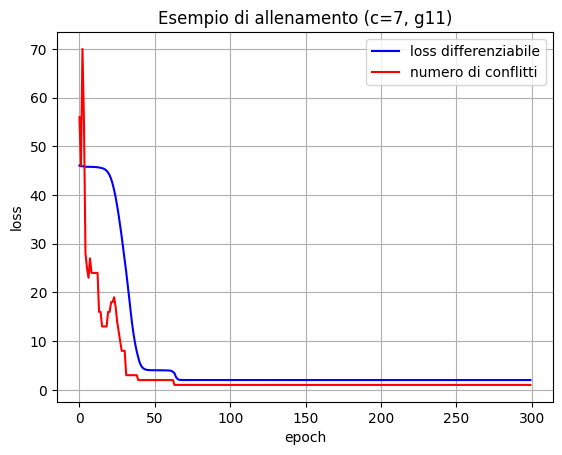

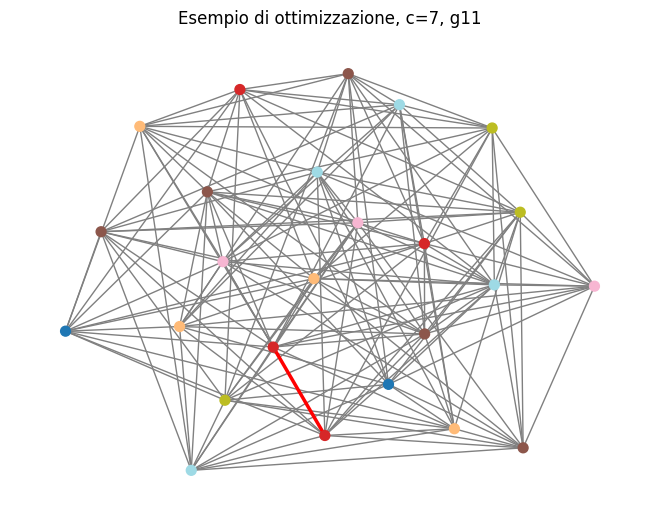

In [ ]:
plt.figure()
plt.plot(train_curve, label = 'loss differenziabile', color = 'blue')
plt.plot(conflicts_curve, label = 'numero di conflitti', color = 'red')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.title(f'Esempio di allenamento (c={c}, g11)')
plt.grid()
plt.legend()

def disegna_grafo_conflitti(model, data):
    node_colors = torch.argmax(model(data), dim=-1).cpu().numpy()
    #print(node_colors)
    G = to_networkx(data, to_undirected=True)
    pos = nx.spring_layout(G)
    nx.draw(
        G,
        pos,
        node_color=node_colors,
        edge_color='gray',
        node_size=50,
        font_size=10,
        cmap=plt.cm.tab20,
    )
    vertici_conflitti = []
    for i, j in G.edges():
        if node_colors[i] == node_colors[j]:
            vertici_conflitti.append((i, j))

    nx.draw_networkx_edges(
            G, pos,
            edgelist=vertici_conflitti,
            edge_color='red',
            width=2.5
        )
plt.figure()
disegna_grafo_conflitti(model11, data11)
plt.title(f'Esempio di ottimizzazione, c={c}, g11')

In [ ]:
# preparo le funzioni per fare più allenamenti
import numpy as np
def oneTrain(data, c, num_epochs=400, ll=0.05):
    # imposto l'iper-parametro
    LAMBDA_MAX = ll
    RAMP_EPOCHS = 200  # massimo valore dopo 200 epoche

    data.x = torch.randn(data.num_nodes, 1)
    data = data.to(device)
    model = ColoraGrafo(num_nodes = data.num_nodes, c=c, hidden=128).to(device)
    optimizer = optim.Adam(model.parameters(), lr = 0.003)
    model.train()
    current_lambda = 0
    for epoch in range(num_epochs):

        # forward pass
        output = model(data)
        loss = my_loss(output, data.edge_index, ll=current_lambda)

        # backward pass and backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # calcolo i conflitti
        #model11.eval()
        conflicts = pott_energy_normal(output, data.edge_index)
        # comincio ad alzare il contributo entropico
    if epoch > 300:
        current_lambda = LAMBDA_MAX * min(1.0, epoch / RAMP_EPOCHS)

        # salvo loss e conflitti
        #print(f"Epoch {epoch+1}, Loss: {loss:.4f}, Conflicts: {conflicts:.4f}")


    return loss.cpu().detach().numpy(), conflicts.cpu().detach().numpy()


def train_ensemble(data, c, num_sim=50, num_epochs=400, ll=0):
    conflitti = []
    colorazioni_perfette = 0
    for i in range(num_sim):
        temp, temp1 = oneTrain(data, c, num_epochs=num_epochs, ll=ll)
        conflitti.append(temp1)
        if temp1==0:
            colorazioni_perfette+=1

    conflitti = np.array([conflitti])
    return conflitti.mean(), conflitti.std(), colorazioni_perfette



In [ ]:
# adesso i loop di allenamenti
cmin = 2
cmax = 9
conflitti_medie = []
conflitti_std = []
frequenze_colorazioni = []
for c in range(cmin, cmax):
    media, dev, colorazioni_perfette = train_ensemble(data11, c, ll=0.05)
    conflitti_medie.append(media)
    conflitti_std.append(dev)
    frequenze_colorazioni.append(colorazioni_perfette/float(50))
    print(c, media, dev,colorazioni_perfette)


2 123.44 1.3879481258317978 0
3 61.04 1.799555500672319 0
4 30.8 3.666060555964672 0
5 12.36 5.624091037669998 5
6 4.36 3.0117104774529704 11
7 1.44 1.92 28
8 0.36 0.7683749084919419 41


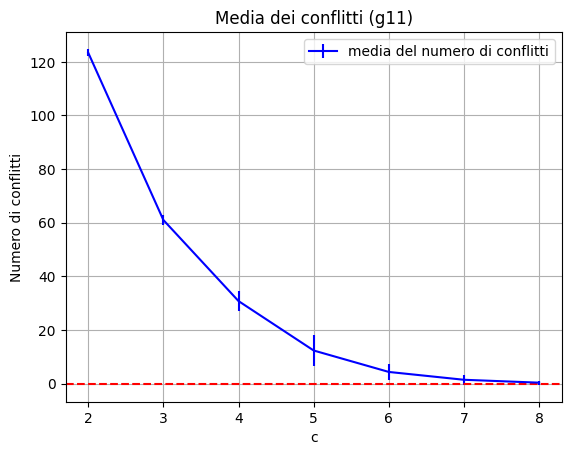

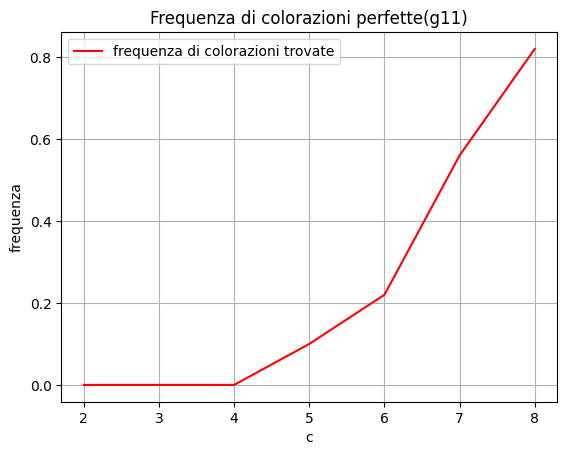

In [ ]:
plt.figure()
plt.errorbar(range(cmin, cmax), conflitti_medie, yerr=conflitti_std, label = 'media del numero di conflitti', color = 'blue')
plt.axhline(0, color='red', linestyle='--')

plt.title('Media dei conflitti (g11)')
plt.grid()
plt.xlabel('c')
plt.ylabel('Numero di conflitti')
plt.legend()

plt.figure()
plt.title('Frequenza di colorazioni perfette(g11)')
plt.xlabel('c')
plt.grid()
plt.ylabel('frequenza')
plt.plot(range(cmin, cmax), frequenze_colorazioni, color = 'red', label = 'frequenza di colorazioni trovate')
plt.legend()

## Risultati

### Grafo `g11`

Il grafo `g11` ha $|V| = 25$ nodi e $|E| = 160$ archi non orientati (rapporto
archi/nodi $\approx 6.4$). La baseline greedy produce una colorazione con $c = 7$ colori.

I risultati dell'ensemble con 50 esecuzioni indipendenti per ciascun valore di $c$, con
400 epoche e $\lambda = 0.05$, sono riportati nella tabella seguente.

**Risultati ensemble su `g11`**

| $c$ (colori) | Media conflitti | Dev. std conflitti | Colorazioni valide |
| --- | --- | --- | --- |
| 2 | 123.44 | 1.39 | 0/50 |
| 3 | 61.04 | 1.80 | 0/50 |
| 4 | 30.80 | 3.67 | 0/50 |
| 5 | 12.36 | 5.62 | **5/50** |
| 6 | 4.36 | 3.01 | 11/50 |
| 7 | 1.44 | 1.92 | 28/50 |
| 8 | 0.36 | 0.77 | 41/50 |

Il numero medio di conflitti diminuisce monotonicamente all'aumentare di $c$, come atteso. Il comportamento della
deviazione standard è particolarmente informativo: il valore elevato per $c = 5$ (5.62)
indica che in quella regione critica il risultato è molto sensibile all'inizializzazione
casuale, con alcune esecuzioni che trovano la colorazione ottima e altre che restano
intrappolate in minimi locali con molti conflitti.

Con $c = 5$, 5 esecuzioni su 50 (10%) hanno prodotto una colorazione con zero conflitti.
Poiché è stata concretamente trovata una colorazione valida con 5 colori, si può affermare
con certezza che $\chi(\texttt{g11}) \leq 5$. Il risultato migliora notevolmente la
baseline greedy, che usava 7 colori.

Con $c = 4$, nessuna delle 50 esecuzioni ha trovato una colorazione valida e la media dei
conflitti (30.8) è molto alta. Questo suggerisce con forza che $\chi(\texttt{g11}) > 4$,
pur non costituendo una prova matematica (il metodo GNN potrebbe semplicemente fallire
l'ottimizzazione anche quando la soluzione esiste).

# Addestro il grafo 17

In [ ]:
# baseline greedy con greedy_color
G = to_networkx(data17, to_undirected=True)
coloring_greedy = nx.coloring.greedy_color(G, strategy="largest_first")
num_colors = max(coloring_greedy.values()) + 1
print("Baseline greedy: c=", num_colors)

Baseline greedy: c= 32


In [ ]:
# proviamo a vedere se il confronto con la basline greedy permette di imparare più facilmente
def calculate_overlap(greedy_coloring, pred):
    overlap = 0
    for key in greedy_coloring:
        overlap += pred[key,coloring_greedy[key]]
    return overlap

In [ ]:
# proviamo a vedere che tutto funzioni
data17.x = torch.randn(data17.num_nodes, 1)
data17 = data17.to(device)

model = ColoraGrafo(num_nodes=data17.num_nodes, c=32, hidden=128, deeper=False).to(device)
pred = model(data17)
loss = my_loss(pred, data17.edge_index, 0.01)
conflitti = pott_energy_normal(pred, data17.edge_index)

print('Loss: ', loss.item())
print('N conflitti: ', conflitti.item())

Loss:  132.63560485839844
N conflitti:  307.0


In [ ]:
import torch.optim as optim
num_epochs = 1000
c=32
# imposto l'iper-parametro
LAMBDA_MAX = 0.1
RAMP_EPOCHS = 200  # massimo valore dopo 200 epoche

# inizializzazione casuale dei pesi
data17.x = torch.randn(data17.num_nodes, 1)
data = data17.to(device)
num_edges = data.num_edges
model17 = ColoraGrafo(num_nodes=data.num_nodes, c=c, hidden=256, deeper=False).to(device)
optimizer17 = optim.Adam(model17.parameters(), lr = 0.003)


train_curve = []
conflicts_curve = []
current_lambda = 0
for epoch in range(num_epochs):
    model17.train()

    # forward pass
    output = model17(data)
    loss = my_loss(output, data.edge_index, current_lambda)

    # backward pass and backpropagation
    optimizer17.zero_grad()
    loss.backward()
    optimizer17.step()

    # calcolo i conflitti
    #model17.eval()
    #output = model17(data)
    conflicts = pott_energy_normal(output, data.edge_index)

    # salvo loss e conflitti
    train_curve.append(loss.cpu().detach().numpy())
    conflicts_curve.append(conflicts.cpu().detach().numpy())

    # comincio ad alzare il contributo entropico
    if epoch > 300:
        current_lambda = LAMBDA_MAX * min(1.0, epoch / RAMP_EPOCHS)

    print(f"Epoch {epoch+1}, Loss: {loss:.4f}, Conflicts: {conflicts:.4f}, Entropy weight: {ll:.2f}")




Epoch 1, Loss: 133.2242, Conflicts: 1059.0000, Entropy weight: 0.00
Epoch 2, Loss: 137.9776, Conflicts: 907.0000, Entropy weight: 0.00
Epoch 3, Loss: 133.1276, Conflicts: 657.0000, Entropy weight: 0.00
Epoch 4, Loss: 132.5275, Conflicts: 522.0000, Entropy weight: 0.00
Epoch 5, Loss: 132.3140, Conflicts: 320.0000, Entropy weight: 0.00
Epoch 6, Loss: 132.2062, Conflicts: 302.0000, Entropy weight: 0.00
Epoch 7, Loss: 132.1676, Conflicts: 372.0000, Entropy weight: 0.00
Epoch 8, Loss: 132.1557, Conflicts: 350.0000, Entropy weight: 0.00
Epoch 9, Loss: 132.1489, Conflicts: 373.0000, Entropy weight: 0.00
Epoch 10, Loss: 132.1385, Conflicts: 398.0000, Entropy weight: 0.00
Epoch 11, Loss: 132.1255, Conflicts: 392.0000, Entropy weight: 0.00
Epoch 12, Loss: 132.1133, Conflicts: 446.0000, Entropy weight: 0.00
Epoch 13, Loss: 132.1030, Conflicts: 410.0000, Entropy weight: 0.00
Epoch 14, Loss: 132.0941, Conflicts: 356.0000, Entropy weight: 0.00
Epoch 15, Loss: 132.0869, Conflicts: 298.0000, Entropy w

In [ ]:
def count_conflicts(edge_list, node_colors):
    """Utility function to count total conflicts."""
    conflicts = 0
    conflict_edges = []
    for u, v in edge_list:
        if node_colors[u] == node_colors[v]:
            conflicts += 1
            conflict_edges.append((u, v))
    return conflicts, conflict_edges

def apply_post_processing(edge_list, node_colors, num_colors):
    """
    Greedy post-processing to reduce residual conflicts.
    """
    improved = True

    # Ripetere finché possibile
    while improved:
        improved = False

        # Identificare gli archi in conflitto
        current_conflicts, conflict_edges = count_conflicts(edge_list, node_colors)

        if current_conflicts == 0:
            break # The coloring is already perfectly valid!

        for u, v in conflict_edges:
            original_color_u = node_colors[u]
            best_color_u = original_color_u
            min_conflicts = current_conflicts

            # Per uno dei due nodi coinvolti, provare a cambiare colore
            for c in range(num_colors):
                if c == original_color_u:
                    continue

                node_colors[u] = c
                new_conflicts, _ = count_conflicts(edge_list, node_colors)

                # Accettare il cambiamento se riduce il numero di conflitti
                if new_conflicts < min_conflicts:
                    min_conflicts = new_conflicts
                    best_color_u = c

            if min_conflicts < current_conflicts:
                # We found a color that reduces conflicts! Keep it and restart the search.
                node_colors[u] = best_color_u
                improved = True
                break # Break the inner loop to recalculate the new conflict edges
            else:
                # Revert back if no improvement was found for node u
                node_colors[u] = original_color_u

    return node_colors

node_colors = torch.argmax(model17(data17), dim=-1).cpu().numpy()
edges = data17.edge_index.cpu().numpy().T

# situazione prima del post-processing
conflicts, _ = count_conflicts(edges, node_colors)
print(conflicts/2)

new_colors = apply_post_processing(edges, node_colors, c)
conflicts, _ = count_conflicts(edges, new_colors)
print(conflicts/2)


5.0
3.0


Text(0.5, 1.0, 'Esempio di ottimizzazione, c=32, g17')

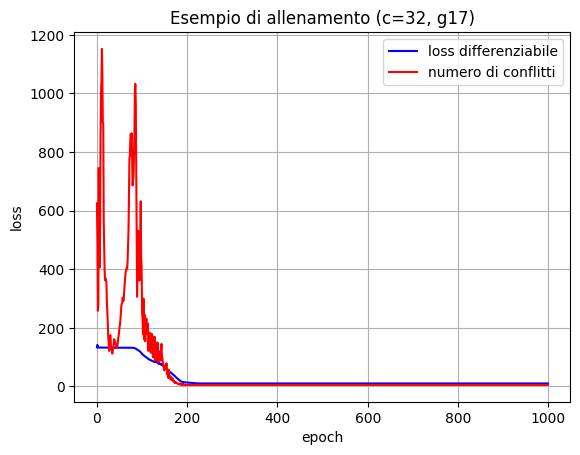

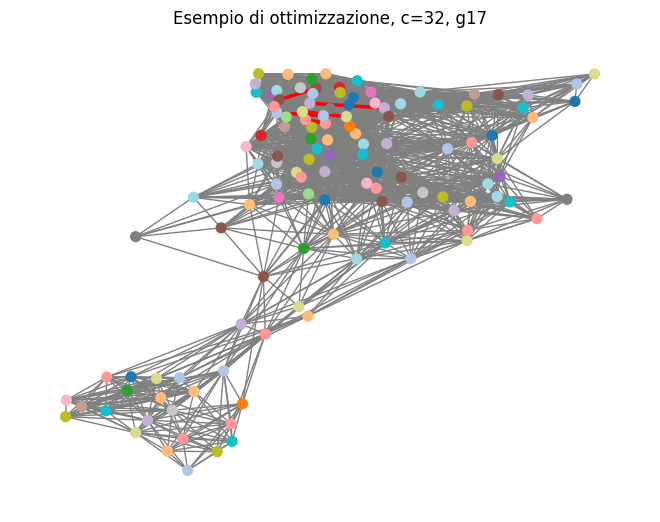

In [ ]:
plt.figure()
plt.plot(train_curve, label = 'loss differenziabile', color = 'blue')
plt.plot(conflicts_curve, label = 'numero di conflitti', color = 'red')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.title(f'Esempio di allenamento (c={c}, g17)')
plt.grid()
plt.legend()

plt.figure()
disegna_grafo_conflitti(model17, data17)
plt.title(f'Esempio di ottimizzazione, c={c}, g17')

In [ ]:
# adesso i loop di allenamenti
cmin = 30
cmax = 38
conflitti_medie = []
conflitti_std = []
frequenze_colorazioni = []
for c in range(cmin, cmax):
    media, dev, colorazioni_perfette = train_ensemble(data17, c, num_epochs=500, ll=0.1)
    conflitti_medie.append(media)
    conflitti_std.append(dev)
    frequenze_colorazioni.append(colorazioni_perfette/float(50))
    print(c, media, dev,colorazioni_perfette)

30 7.14 0.91673326 0
31 6.36 1.072567 0
32 5.2 0.8 0
33 4.66 1.0697663 0
34 3.82 1.0332474 0
35 2.74 1.0160708 1
36 2.14 1.0584894 3
37 1.76 1.1235658 6


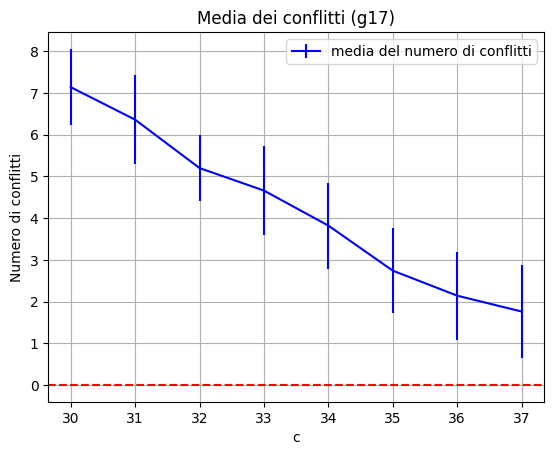

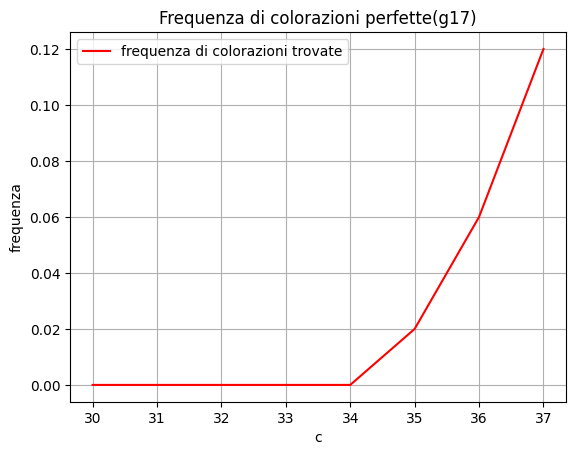

In [ ]:
plt.figure()
plt.errorbar(range(cmin, cmax), conflitti_medie, yerr=conflitti_std, label = 'media del numero di conflitti', color = 'blue')
plt.axhline(0, color='red', linestyle='--')

plt.title('Media dei conflitti (g17)')
plt.grid()
plt.xlabel('c')
plt.ylabel('Numero di conflitti')
plt.legend()

plt.figure()
plt.title('Frequenza di colorazioni perfette(g17)')
plt.xlabel('c')
plt.grid()
plt.ylabel('frequenza')
plt.plot(range(cmin, cmax), frequenze_colorazioni, color = 'red', label = 'frequenza di colorazioni trovate')
plt.legend()

### Grafo `g17`

Il grafo `g17` ha $|V| = 128$ nodi e $|E| = 2113$ archi non orientati (rapporto
archi/nodi $\approx 16.5$). La baseline greedy produce una colorazione con $c = 32$
colori. La scansione è stata effettuata a partire da $c = 30$ (leggermente al di sotto
della baseline) fino a $c = 37$, con 50 esecuzioni e 500 epoche ciascuna.

**Risultati ensemble su `g17`**

| $c$ (colori) | Media conflitti | Dev. std conflitti | Colorazioni valide |
| --- | --- | --- | --- |
| 30 | 7.14 | 1.18 | 0/50 |
| 31 | 6.36 | 1.15 | 0/50 |
| 32 | 5.2 | 0.97 | 0/50 |
| 33 | 4.66 | 0.88 | 0/50 |
| 34 | 3.82 | 0.87 | 0/50 |
| 35 | 2.74 | 0.77 | **1/50** |
| 36 | 2.14 | 0.90 | 3/50 |
| 37 | 1.76 | 0.88 | 6/50 |

Per `g17`, il primo valore di $c$ per cui il metodo ha trovato colorazioni valide
è $c = 35$ (1 esecuzione su 50, ossia il 2%). Con $c = 37$ si ottengono 5 colorazioni
valide su 50 (10%). Si conclude quindi che $\chi(\texttt{g17}) \leq 35$.

Il tasso di successo è decisamente inferiore rispetto a `g11` a parità di distanza
dalla soglia critica, il che riflette la maggiore difficoltà combinatoria del grafo: con
2113 archi su 128 nodi, i vincoli di colorazione sono molto più fitti e i minimi locali
della loss più numerosi.

Per valori $c \leq 34$, nessuna delle 50 esecuzioni ha prodotto una colorazione valida.
La media dei conflitti decresce lentamente ma non raggiunge lo zero, indicando che il processo di minimizzazione della loss si blocca in minimi locali.

## Discussione
Si riporta qui una discussione critica dei riultati ottenuti. Il fatto che ci sia una fluttuazione non indifferente nel numero di conflitti ottenuti a parità di numero di colori indica che la convergenza del metodo non sia garantita. L'eventuale raggiungimento di una colorazione ottimale non è quindi garantito e può cambiare in base all'inizializzazione iniziali dei pesi della rete. Per `g11` con $c = 5$, solo il 10% delle
esecuzioni trova la colorazione valida, con una deviazione standard dei conflitti di 5.62,
quasi la metà della media stessa (12.36). Per `g17` con $c = 36$, la frequenza di
successo è solo del 6%.

Per `g11` si sono trovate configurazioni ottimali anche con $c=5$, migliorando di due i risultati ottenuti dalla baseline greedy. Per quanto riguarda `g17` il meglio che si è riusciti a fare è con 35 colori, 3 in più della baseline greedy. 

Il solo monitoraggio della loss non è sufficiente a capire la qualità delle soluzioni proposte dalla rete, in quando essa può tentare di di proporre soluzioni meno nette per minimizzare la loss senza realmente diminuire il numero di conflitti. Per evitare questo comportamento si è aggiunto un termine entropico che favoriva assegnazioni più nette e un maggiore allineamento tra minimizzazione della loss e del numero di conflitti. 

Nel corso dell'allenamento delle GNN con i due grafi si sono riscontrati diversi limiti per un approccio di questo tipo: 
- In base all'inizializzazione, è possibile che la rete si accontenti di un minimo locale della loss e non trovi la colorazione ottimale anche dove sarebbe possibile trovarla. Questo fa sì che bisogni fare più allenamenti con inizializzazioni diverse e rende quindi l'analisi più complessa dal punto di vista computazionale. 
- Il fatto che numero di epoche e iperparametri vadano regolati per ogni istanza del grafo fa sì che il compito di trovare una colorazione ottimale sia poco automatizzato. 

Come possibili migliorie del metodo di propongono:
- Migliorare lo scheduling del contributo entropico e del learning rate per permettere alla rete di esplorare con più libertà la loss landscape nelle fasi iniziali dell'addestramento.
- Utilizzare la soluzione trovata con il metodo greedy per aggiungere alla loss un termine che favorisca configurazioni che hanno overlap con essa (magari con un iperparametro che diminuisce nel corso dell'addestramento).